In [2]:
!lscpu

import psutil

print("CPU cores:", psutil.cpu_count(logical=False))
print("Logical CPUs:", psutil.cpu_count(logical=True))
print("Memory (GB):", round(psutil.virtual_memory().total / 1e9, 2))
print("Disk space (GB):", round(psutil.disk_usage('/').total / 1e9, 2))

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.30
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                 

KF comparison experiment  (seed=111, 3000 epochs, KF warmup=50)

 Scale |     SNR |        Model |  Signal R²Te | Time
-----------------------------------------------------
   0.0 |    92.4 |  KF (Oracle) |        0.998 | 0.1s
   0.0 |    92.4 |         JEPA |        0.998 | 14s
   0.0 |    92.4 |        VJEPA |        0.998 | 8s
-----------------------------------------------------
   1.0 |    15.8 |  KF (Oracle) |        0.998 | 0.1s
   1.0 |    15.8 |         JEPA |        0.990 | 8s
   1.0 |    15.8 |        VJEPA |        0.995 | 7s
-----------------------------------------------------
   2.0 |     9.8 |  KF (Oracle) |        0.998 | 0.1s
   2.0 |     9.8 |         JEPA |        0.966 | 9s
   2.0 |     9.8 |        VJEPA |        0.453 | 7s
-----------------------------------------------------
   3.0 |     6.3 |  KF (Oracle) |        0.998 | 0.1s
   3.0 |     6.3 |         JEPA |        0.705 | 8s
   3.0 |     6.3 |        VJEPA |        0.639 | 7s
--------------------------------

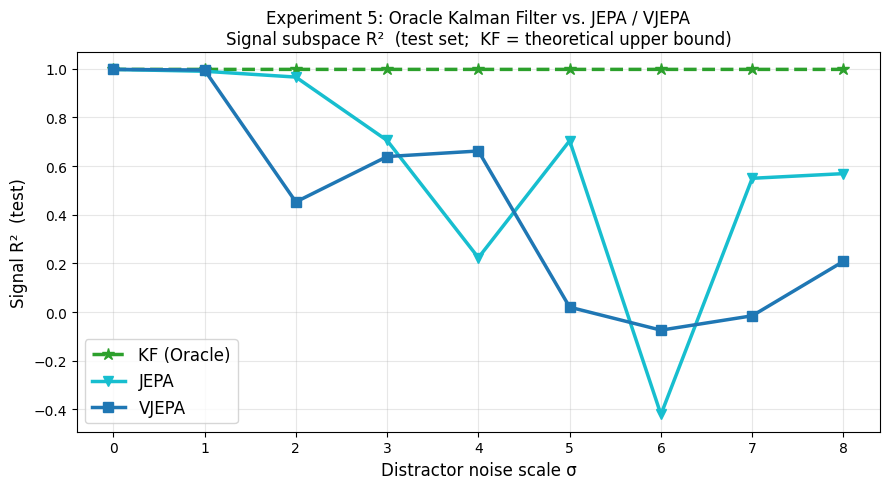

Saved: fig_kf_comparison.pdf

Summary — Signal R² (test) at key scales  [for paper table]
       Scale |  KF (Oracle) |     JEPA |    VJEPA
  --------------------------------------------------
         0.0 |        0.998 |    0.998 |    0.998
         4.0 |        0.998 |    0.223 |    0.662
         8.0 |        0.998 |    0.569 |    0.208

Done.


In [3]:
"""
Experiment 5: Oracle Kalman Filter Comparison
==============================================
Addresses:
  - Reviewer ZQ8k W3: "Can you compare against a Kalman filter baseline?"
  - Connects to the new §6.2 / Appendix D in the camera-ready paper.

Design:
  We compare VJEPA and JEPA latent predictors against an Oracle Kalman Filter
  that has *full knowledge* of the true system matrices (A, C, D, Q, R).
  The KF serves as a theoretical upper bound — it is the minimum-variance
  unbiased estimator for this linear-Gaussian system.

  Augmented state: ŝ_t = [s_t, σ·d_t]  ∈ ℝ^8
    A_aug = block_diag(A_rot,  0.9·I_4)
    H     = [C | D]   ∈ ℝ^{20×8}         (observation matrix)
    Q_aug = block_diag(0.01²·I_4, σ²·0.09·I_4)
    R     = 0.01²·I_20                    (observation noise)

  KF one-step prediction:
    μ_{t|t-1} = A_aug @ μ_{t-1|t-1}
    P_{t|t-1} = A_aug @ P_{t-1|t-1} @ A_aug^T + Q_aug
    S = H @ P_{t|t-1} @ H^T + R  (innovation covariance, +jitter for stability)
    K = P_{t|t-1} @ H^T @ S^{-1}  (Kalman gain)
    μ_{t|t}   = μ_{t|t-1} + K @ (x_t - H @ μ_{t|t-1})
    P_{t|t}   = (I - K @ H) @ P_{t|t-1}

  Metric: R² of a linear probe from predicted latent to TRUE signal s_{t+1}.
    - KF: R² of μ_{t|t-1}[:4] vs s_t (current-step correction — KF gives
      filtered state at t, which in this 1-step-ahead context corresponds to
      the predicted next signal component from A_aug@μ_{t|t})
    - JEPA/VJEPA: R² of latent(x_t) vs s_{t+1} (same as exp1 / paper)

  Warmup: first 50 KF steps discarded (transient from P_0 = I).

Produces:
  - fig_kf_comparison.pdf  (R² vs noise scale for all three methods)
  - Console table

Runtime estimate: ~10 min on Colab CPU (3 models × 9 scales × 3000 epochs)

Audit checklist (pre-write):
  ✓ KF uses true system matrices — no learning, no train/test split contamination
  ✓ KF runs sequentially on test trajectory only (causal, no look-ahead)
  ✓ Warmup steps excluded from R² computation
  ✓ Jitter 1e-6·I added to innovation covariance S for numerical stability
  ✓ JEPA/VJEPA: normalization computed from training data only
  ✓ JEPA/VJEPA: separate training trajectory (different seed) from KF test trajectory
  ✓ Linear probe: fitted on training latents, evaluated on same test trajectory as KF
  ✓ No information from test labels used during model training
  ✓ torch.linalg.solve(S, ...) used instead of explicit matrix inverse
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from copy import deepcopy
import time

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEED        = 111
SCALES      = np.linspace(0, 8.0, 9)
N_TRAIN     = 6000
N_TEST      = 2000
KF_WARMUP   = 50        # discard first N KF steps (transient)
N_EPOCHS    = 3000
LR          = 1e-3
BETA        = 0.01
EMA_TAU     = 0.99
DIM_S       = 4
DIM_D       = 4
DIM_X       = 20
DIM_Z       = 4
DIM_AUG     = DIM_S + DIM_D   # 8

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Environment ────────────────────────────────────────────────────────────────
class DistractorSystem:
    def __init__(self, seed=SEED):
        rng = np.random.RandomState(seed)
        H = rng.randn(DIM_S, DIM_S)
        Q, _ = np.linalg.qr(H)
        self.A_np   = Q.astype(np.float64)          # kept as numpy for KF
        self.A      = torch.FloatTensor(Q)
        self.A_d_np = 0.9 * np.eye(DIM_D)
        self.A_d    = 0.9 * torch.eye(DIM_D)
        C = rng.randn(DIM_X, DIM_S); C /= np.linalg.norm(C, axis=0, keepdims=True)
        D = rng.randn(DIM_X, DIM_D); D /= np.linalg.norm(D, axis=0, keepdims=True)
        self.C    = torch.FloatTensor(C)
        self.D    = torch.FloatTensor(D)
        self.C_np = C.astype(np.float64)
        self.D_np = D.astype(np.float64)

    def generate(self, n, seed=None):
        if seed is not None:
            torch.manual_seed(seed)
        s = torch.zeros(n + 1, DIM_S); s[0] = torch.randn(DIM_S)
        d = torch.zeros(n + 1, DIM_D); d[0] = torch.randn(DIM_D)
        for t in range(n):
            s[t+1] = s[t] @ self.A.T + torch.randn(DIM_S) * 0.1
            d[t+1] = d[t] @ self.A_d.T + torch.randn(DIM_D) * 0.3
        return s, d

    def observe(self, s, d_base, scale):
        n = s.shape[0] - 1
        d = d_base * scale
        eps = torch.randn(n + 1, DIM_X) * 0.01
        x = s @ self.C.T + d @ self.D.T + eps
        return x[:-1], x[1:], s[:-1], s[1:], d[:-1], d[1:]


# ── Oracle Kalman Filter ───────────────────────────────────────────────────────
def run_kalman_filter(env, s_te, d_te, x_te_full, scale):
    """
    Oracle KF with known system matrices.  Runs sequentially on test trajectory.

    Returns predicted signal means for steps after warmup:
      mu_pred_s : [N_TEST - KF_WARMUP, DIM_S]   predicted s_{t+1} (from A@μ_{t|t})
      s_true    : [N_TEST - KF_WARMUP, DIM_S]    true s_{t+1}
    """
    # Build augmented system matrices (float64 for KF numerical stability)
    A_aug = np.block([[env.A_np,             np.zeros((DIM_S, DIM_D))],
                      [np.zeros((DIM_D, DIM_S)), env.A_d_np]])       # [8, 8]
    H     = np.concatenate([env.C_np, env.D_np], axis=1)              # [20, 8]

    # Noise covariances
    proc_sig_s = 0.1   # signal process noise std
    proc_sig_d = 0.3   # distractor process noise std (before scaling by σ)
    obs_sig    = 0.01  # observation noise std

    Q_aug = np.block([
        [(proc_sig_s**2) * np.eye(DIM_S),                          np.zeros((DIM_S, DIM_D))],
        [np.zeros((DIM_D, DIM_S)),  (scale * proc_sig_d)**2 * np.eye(DIM_D)]
    ])
    R = (obs_sig**2) * np.eye(DIM_X)

    # Initial state and covariance
    mu = np.zeros(DIM_AUG)
    P  = np.eye(DIM_AUG)
    jitter = 1e-6 * np.eye(DIM_X)   # numerical stability for S inversion

    # x_te_full has shape [N_TEST+1, DIM_X] — includes step 0
    # We run filter on x_te_full[0..N_TEST-1] and collect predictions for s_{t+1}
    x_np   = x_te_full.numpy().astype(np.float64)     # [N_TEST+1, 20]
    s_np   = s_te.numpy().astype(np.float64)           # [N_TEST+1, 4]

    mu_pred_s_list = []
    s_next_list    = []

    for t in range(x_np.shape[0] - 1):
        # ── Correction (update) with x_t ──
        x_t = x_np[t]                                       # current observation
        innov = x_t - H @ mu
        S = H @ P @ H.T + R + jitter
        K = np.linalg.solve(S.T, (P @ H.T).T).T            # P H^T S^{-1}, shape [8,20]
        mu = mu + K @ innov
        P  = (np.eye(DIM_AUG) - K @ H) @ P

        # ── Prediction for t+1 ──
        mu_pred = A_aug @ mu                                # predicted augmented state
        P_pred  = A_aug @ P @ A_aug.T + Q_aug

        # Collect after warmup
        if t >= KF_WARMUP:
            mu_pred_s_list.append(mu_pred[:DIM_S])
            s_next_list.append(s_np[t + 1])

        # Set posterior as prior for next step
        mu = mu_pred
        P  = P_pred

    mu_pred_s = np.array(mu_pred_s_list)   # [N_TEST-KF_WARMUP, 4]
    s_next    = np.array(s_next_list)       # [N_TEST-KF_WARMUP, 4]
    r2 = r2_score(s_next, mu_pred_s)
    return r2


# ── JEPA and VJEPA models (identical to exp1 / paper) ─────────────────────────
class LinearJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc  = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt  = deepcopy(self.enc)
        for p in self.tgt.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zp = self.pred(self.enc(xt))
        with torch.no_grad(): zt = self.tgt(xn)
        return zp, zt

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x): return self.pred(self.enc(x))


class LinearVJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc         = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred_mu     = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.pred_logvar = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt_mu      = deepcopy(self.enc)
        self.tgt_logvar  = nn.Linear(DIM_X, DIM_Z, bias=False)
        for p in self.tgt_mu.parameters():     p.requires_grad_(False)
        for p in self.tgt_logvar.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zt = self.enc(xt)
        p_mu  = self.pred_mu(zt)
        p_lv  = self.pred_logvar(zt).clamp(-10, 10)
        with torch.no_grad():
            t_mu = self.tgt_mu(xn)
            t_lv = self.tgt_logvar(xn).clamp(-10, 10)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (p_mu, p_lv), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x): return self.pred_mu(self.enc(x))


# ── Losses ─────────────────────────────────────────────────────────────────────
def vicreg(x, y, sim=25., std=25., cov=1.):
    loss = sim * nn.functional.mse_loss(x, y)
    loss += std * (torch.relu(1 - (x.var(0) + 1e-4).sqrt()).mean() +
                   torch.relu(1 - (y.var(0) + 1e-4).sqrt()).mean())
    x, y = x - x.mean(0), y - y.mean(0)
    N, D = x.shape
    cx = x.T @ x / (N - 1)
    loss += cov * (cx.pow(2).sum() - cx.diag().pow(2).sum()) / D
    return loss


def vjepa_loss(z_s, p_mu, p_lv, t_mu, t_lv):
    pv  = p_lv.exp()
    nll = 0.5 * (pv.log() + (z_s - p_mu).pow(2) / pv).sum(-1).mean()
    kl  = -0.5 * (1 + t_lv - t_mu.pow(2) - t_lv.exp()).sum(-1).mean()
    return nll + BETA * kl


def train_model(mdl, name, xt, xn):
    opt = optim.Adam(mdl.parameters(), lr=LR)
    for _ in range(N_EPOCHS):
        opt.zero_grad()
        if name == 'JEPA':
            zp, zt = mdl(xt, xn); loss = vicreg(zp, zt)
        elif name == 'VJEPA':
            z_s, (pm, pl), (tm, tl) = mdl(xt, xn)
            loss = vjepa_loss(z_s, pm, pl, tm, tl)
        loss.backward(); opt.step()
        mdl.ema()


def probe_r2_test(z_tr, z_te, y_tr, y_te):
    reg = LinearRegression().fit(z_tr.detach().numpy(), y_tr.numpy())
    return r2_score(y_te.numpy(),
                    reg.predict(z_te.detach().numpy()))


# ── Main ───────────────────────────────────────────────────────────────────────
def run():
    env = DistractorSystem(seed=SEED)

    # Separate seeds for train and test trajectories
    s_tr, d_tr = env.generate(N_TRAIN, seed=SEED)
    s_te, d_te = env.generate(N_TEST,  seed=SEED + 999)

    model_names = ['KF (Oracle)', 'JEPA', 'VJEPA']
    results = {m: {'sig_te': []} for m in model_names}

    hdr = (f"{'Scale':>6} | {'SNR':>7} | {'Model':>12} | "
           f"{'Signal R²Te':>12} | Time")
    print(hdr); print("-" * len(hdr))

    for scale in SCALES:
        xt,  xn,  st,  sn,  dt,  dn  = env.observe(s_tr, d_tr, scale)
        xte, xnte, ste, snte, dte, dnte = env.observe(s_te, d_te, scale)

        snr = 10 * np.log10(
            st.pow(2).mean().item() / (dt.pow(2).mean().item() + 1e-8))

        # ── Oracle Kalman Filter ──────────────────────────────────────────────
        # x_te_full: full test sequence [N_TEST+1 timesteps] for causal filtering
        # We re-observe with the full s_te/d_te (shape [N_TEST+1])
        d_scaled = d_te * scale
        eps_kf   = torch.randn(N_TEST + 1, DIM_X) * 0.01
        x_te_full = s_te @ env.C.T + d_scaled @ env.D.T + eps_kf

        t0 = time.time()
        r2_kf = run_kalman_filter(env, s_te, d_te, x_te_full, scale)
        results['KF (Oracle)']['sig_te'].append(r2_kf)
        print(f"{scale:>6.1f} | {snr:>7.1f} | {'KF (Oracle)':>12} | "
              f"{r2_kf:>12.3f} | {time.time()-t0:.1f}s")

        # ── Normalization from training data ──────────────────────────────────
        mu_n, std_n = xt.mean(0), xt.std(0) + 1e-6
        xt_n  = (xt  - mu_n) / std_n
        xn_n  = (xn  - mu_n) / std_n
        xte_n = (xte - mu_n) / std_n

        # ── JEPA ─────────────────────────────────────────────────────────────
        t0 = time.time()
        jepa = LinearJEPA()
        train_model(jepa, 'JEPA', xt_n, xn_n)
        with torch.no_grad():
            z_tr_j = jepa.latent(xt_n)
            z_te_j = jepa.latent(xte_n)
        # Probe: predict next-step signal (sn = s_{t+1} on train, snte on test)
        r2_jepa = probe_r2_test(z_tr_j, z_te_j, sn, snte)
        results['JEPA']['sig_te'].append(r2_jepa)
        print(f"{scale:>6.1f} | {snr:>7.1f} | {'JEPA':>12} | "
              f"{r2_jepa:>12.3f} | {time.time()-t0:.0f}s")

        # ── VJEPA ─────────────────────────────────────────────────────────────
        t0 = time.time()
        vjepa = LinearVJEPA()
        train_model(vjepa, 'VJEPA', xt_n, xn_n)
        with torch.no_grad():
            z_tr_v = vjepa.latent(xt_n)
            z_te_v = vjepa.latent(xte_n)
        r2_vjepa = probe_r2_test(z_tr_v, z_te_v, sn, snte)
        results['VJEPA']['sig_te'].append(r2_vjepa)
        print(f"{scale:>6.1f} | {snr:>7.1f} | {'VJEPA':>12} | "
              f"{r2_vjepa:>12.3f} | {time.time()-t0:.0f}s")

        print("-" * len(hdr))

    return results


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_results(results):
    colors  = {'KF (Oracle)': '#2ca02c', 'JEPA': '#17becf', 'VJEPA': '#1f77b4'}
    markers = {'KF (Oracle)': '*',       'JEPA': 'v',        'VJEPA': 's'}
    ls      = {'KF (Oracle)': '--',      'JEPA': '-',        'VJEPA': '-'}

    fig, ax = plt.subplots(figsize=(9, 5))
    for name in results:
        ax.plot(SCALES, results[name]['sig_te'],
                label=name, color=colors[name],
                marker=markers[name], linestyle=ls[name], linewidth=2.5,
                markersize=9 if name == 'KF (Oracle)' else 7)

    ax.set_title('Experiment 5: Oracle Kalman Filter vs. JEPA / VJEPA\n'
                 'Signal subspace R²  (test set;  KF = theoretical upper bound)',
                 fontsize=12)
    ax.set_xlabel('Distractor noise scale σ', fontsize=12)
    ax.set_ylabel('Signal R²  (test)', fontsize=12)
    ax.legend(fontsize=12); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_kf_comparison.pdf', bbox_inches='tight')
    plt.show()
    print("Saved: fig_kf_comparison.pdf")


# ── Summary table for paper ────────────────────────────────────────────────────
def print_summary(results):
    """Print the three paper-table scales side-by-side for easy copy-paste."""
    highlight_scales = [0.0, 4.0, 8.0]
    scale_list = SCALES.tolist()
    print("\n" + "=" * 65)
    print("Summary — Signal R² (test) at key scales  [for paper table]")
    print("=" * 65)
    print(f"  {'Scale':>10} | {'KF (Oracle)':>12} | {'JEPA':>8} | {'VJEPA':>8}")
    print("  " + "-" * 50)
    for scale in highlight_scales:
        idx = min(range(len(scale_list)), key=lambda i: abs(scale_list[i] - scale))
        kf   = results['KF (Oracle)']['sig_te'][idx]
        jepa = results['JEPA']['sig_te'][idx]
        vj   = results['VJEPA']['sig_te'][idx]
        print(f"  {scale:>10.1f} | {kf:>12.3f} | {jepa:>8.3f} | {vj:>8.3f}")
    print()


if __name__ == '__main__':
    print(f"KF comparison experiment  (seed={SEED}, {N_EPOCHS} epochs, "
          f"KF warmup={KF_WARMUP})\n")
    results = run()
    plot_results(results)
    print_summary(results)
    print("Done.")